# Arctic Atmosphere files 

* **Description**: Creates file of Utqiagvik data from CESM2-LE
* **Input data**: CESM2-le daily timeseries data
* **Output data**: Netcdf with data
* **Creator**: Alice DuVivier
* **Date**: September 2026

### Import Packages

In [1]:
#import utils
import xarray as xr
import numpy as np
from glob import glob
import importlib
from datetime import datetime
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cmocean

## Find point nearest Utqiagvik

In [2]:
# set latitude and longitude of Village (longitudes must be in 0-360)
name_village = 'Utqiagvik'
lat_village = 71.29
lon_village = 203.21
#longitue = -156.79

In [3]:
# set a dataset to read in to get grid information
dir_in = '/glade/u/home/duvivier/masks/'
file_in = 'b.e21.BSSP370.f09_g17.rufmod.001.cam.h0.2015-01.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [4]:
# grab lat and lon data
lat1d = ds.lat
lon1d = ds.lon
land = ds.LANDFRAC

In [5]:
# First, find the index of the grid point nearest a specific lat/lon.   
abslat = np.abs(lat1d - lat_village)
abslon = np.abs(lon1d - lon_village)

# find the smallest values
xloc = np.where(abslat == np.min(abslat))
yloc = np.where(abslon == np.min(abslon))

# print index values
print(xloc[0],yloc[0])

[171] [163]


In [6]:
# Check how close these are to the latitude and longitude of the village
print(name_village+': '+str(lat_village)+','+str(lon_village))

lat_grid = lat1d.isel(lat=xloc[0]).values
lon_grid = lon1d.isel(lon=yloc[0]).values
print('grid point: '+str(lat_grid)+','+str(lon_grid))

Utqiagvik: 71.29,203.21
grid point: [71.15183246],[203.75]


In [7]:
#create a meshgrid (2D fields of lats and lons)
lon2d,lat2d=np.meshgrid(lon1d,lat1d)

# convert the numpy array to an xarray
lon2d = xr.DataArray(lon2d,dims=('lat','lon'))
lat2d = xr.DataArray(lat2d,dims=('lat','lon'))

# assign coordinates
lon2d['lat'] = land.lat
lon2d['lon'] = land.lon
lat2d['lat'] = land.lat
lat2d['lon'] = land.lon

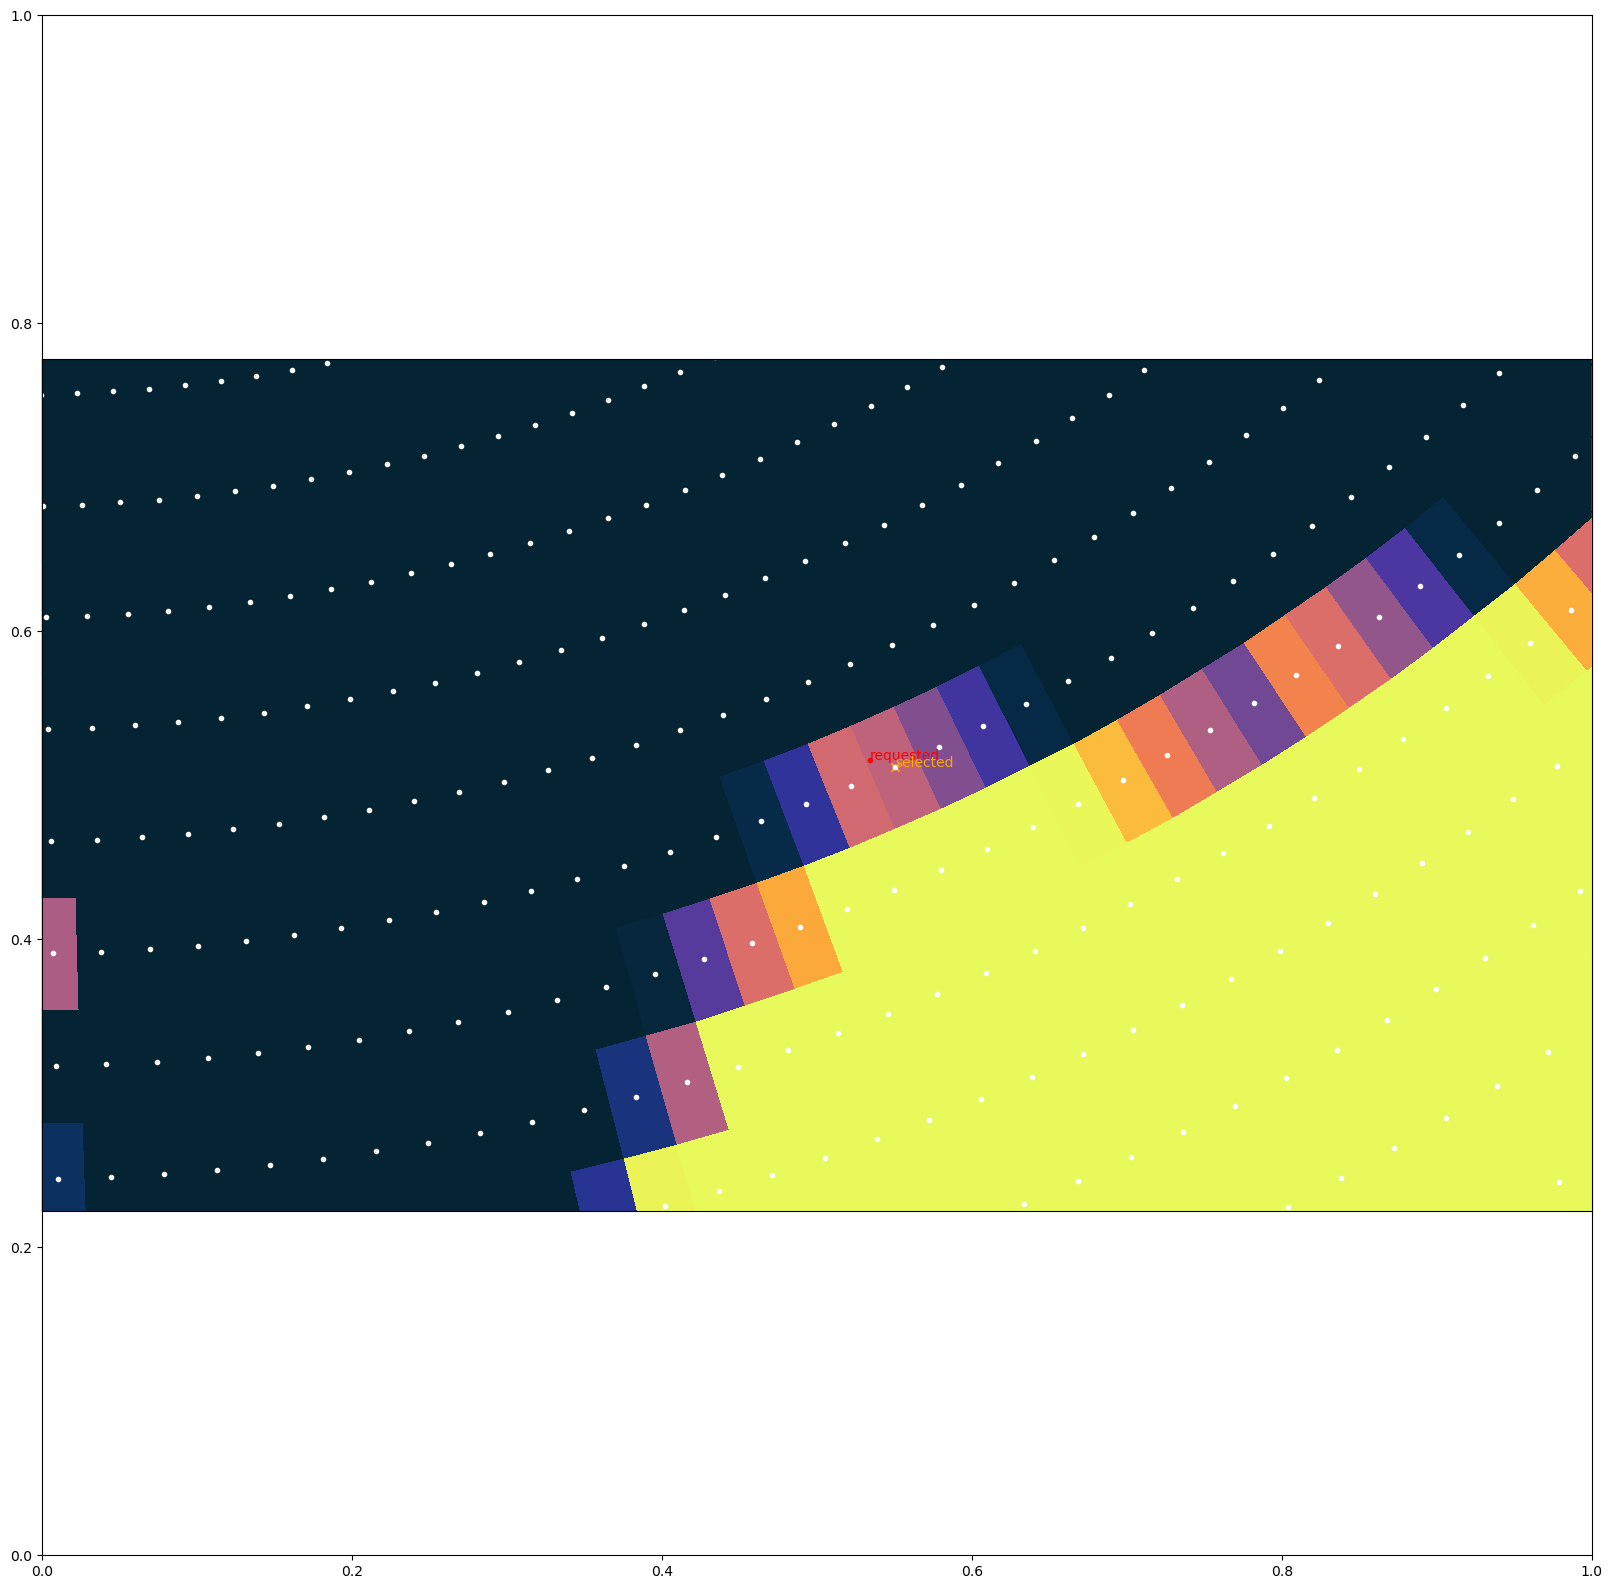

In [8]:
# Plot the Grid points to ensure we have the closest point for plots
fig = plt.figure(figsize=(20,20))

# make plot
ax = plt.subplot(1,1,1)
ax = plt.subplot(1,1,1,projection = ccrs.NorthPolarStereo(central_longitude=180.0) )
ax.set_extent([-140, -179, 72, 69], crs=ccrs.PlateCarree())

# do a pcolormesh plot of input
cs0 = ax.pcolormesh(lon1d, lat1d,
                    land.isel(time=0),
                    cmap = cmocean.cm.thermal, vmin = 0, vmax = 1,
                    transform=ccrs.PlateCarree())

# do scatter plot of all grid values
cs1 = ax.plot(lon2d, lat2d,
                 land.isel(time=0),
                 c='white',marker='.', linestyle='none',
                 transform=ccrs.PlateCarree())

# Plot requested lat/lon point
cs2 = ax.scatter(lon_village, lat_village, marker='.',c='red', transform=ccrs.PlateCarree())
tx1 = ax.text(lon_village, lat_village, 'requested', c='red', transform=ccrs.PlateCarree())

# Plot nearest point in the array red
cs4 = plt.scatter(lon2d.isel(lat=xloc[0],lon=yloc[0]), lat2d.isel(lat=xloc[0],lon=yloc[0]), marker='x', color='orange', transform=ccrs.PlateCarree())
tx2 = plt.text(lon2d.isel(lat=xloc[0],lon=yloc[0]), lat2d.isel(lat=xloc[0],lon=yloc[0]), 'selected', c='orange', transform=ccrs.PlateCarree())
               

- This point is NOT a full ocean point, so we want to grab one latitude further north instead.

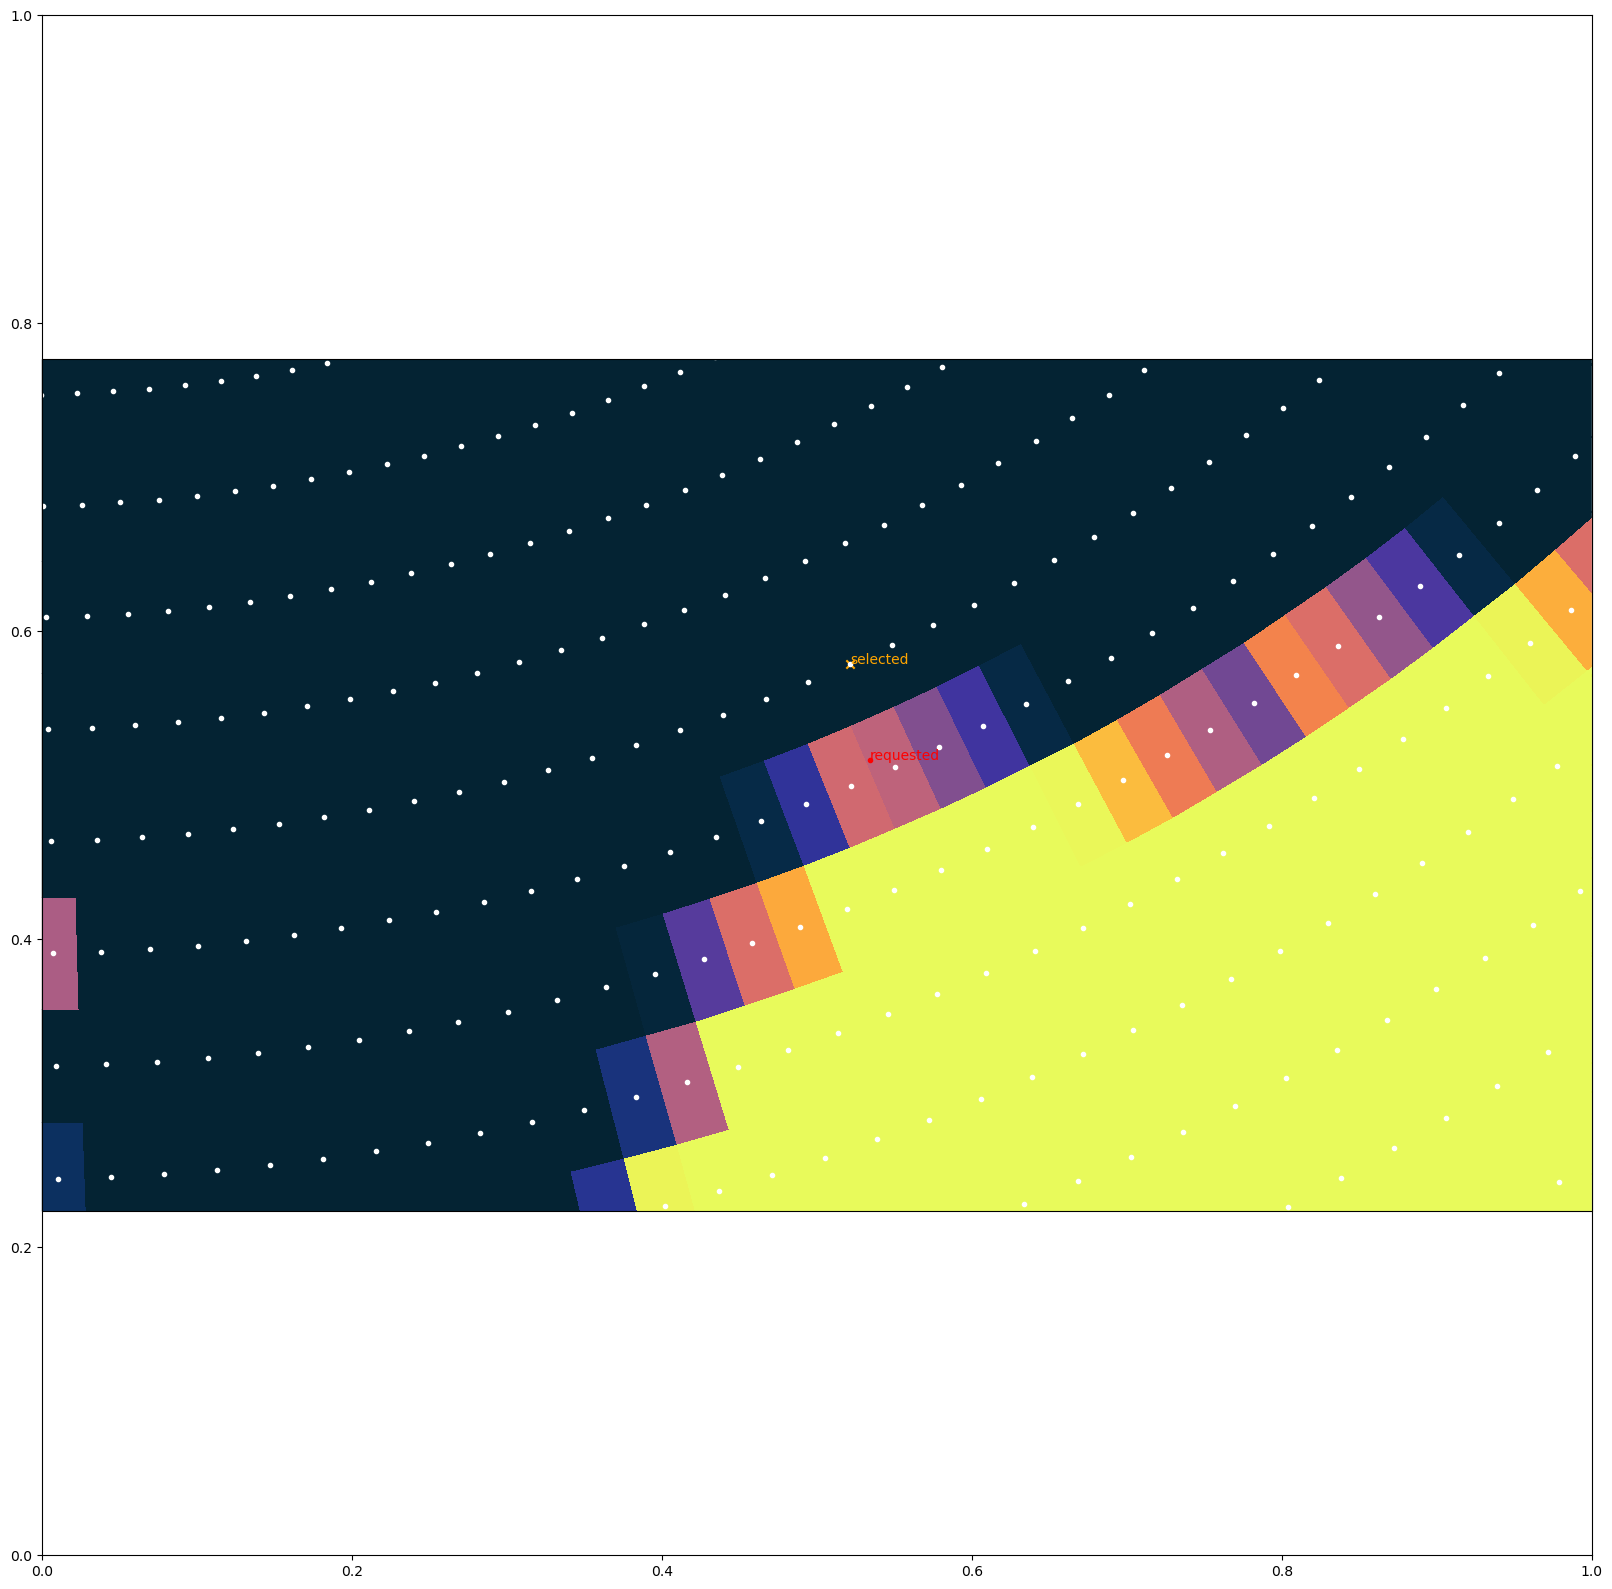

In [9]:
# Plot the Grid points to ensure we have the closest point for plots
fig = plt.figure(figsize=(20,20))

# make plot
ax = plt.subplot(1,1,1)
ax = plt.subplot(1,1,1,projection = ccrs.NorthPolarStereo(central_longitude=180.0) )
ax.set_extent([-140, -179, 72, 69], crs=ccrs.PlateCarree())

# do a pcolormesh plot of input
cs0 = ax.pcolormesh(lon1d, lat1d,
                    land.isel(time=0),
                    cmap = cmocean.cm.thermal, vmin = 0, vmax = 1,
                    transform=ccrs.PlateCarree())

# do scatter plot of all grid values
cs1 = ax.plot(lon2d, lat2d,
                 land.isel(time=0),
                 c='white',marker='.', linestyle='none',
                 transform=ccrs.PlateCarree())

# Plot requested lat/lon point
cs2 = ax.scatter(lon_village, lat_village, marker='.',c='red', transform=ccrs.PlateCarree())
tx1 = ax.text(lon_village, lat_village, 'requested', c='red', transform=ccrs.PlateCarree())

# Plot nearest point in the array red
cs4 = plt.scatter(lon2d.isel(lat=(xloc[0]+1),lon=yloc[0]), lat2d.isel(lat=(xloc[0]+1),lon=yloc[0]), marker='x', color='orange', transform=ccrs.PlateCarree())
tx2 = plt.text(lon2d.isel(lat=(xloc[0]+1),lon=yloc[0]), lat2d.isel(lat=(xloc[0]+1),lon=yloc[0]), 'selected', c='orange', transform=ccrs.PlateCarree())
               

- This point is an ocean point and is closest to the Utqiagvik village. Proceed!

In [10]:
# print original index values
print(xloc[0],yloc[0])

[171] [163]


In [11]:
# set xloc and yloc so they play nicely below
xloc = 172
yloc = 163

In [12]:
# Check how close these are to the latitude and longitude of the village
print(name_village+': '+str(lat_village)+','+str(lon_village))

lat_grid = lat1d.isel(lat=xloc).values
lon_grid = lon1d.isel(lon=yloc).values
print('grid point: '+str(lat_grid)+','+str(lon_grid))

Utqiagvik: 71.29,203.21
grid point: 72.09424083769633,203.75


## Read in 3 CESM2 ensemble members (CMIP6 standard forcing)

In [16]:
# varname options = 'TREFHT','U10'

varname = 'U10'
path = '/glade/campaign/collections/cmip/CMIP6/timeseries-cmip6/'

In [14]:
# list all cmip6 standard forcing ensemble numbers
ens_mems = ['b.e21.BSSP245cmip6.f09_g17.CMIP6-SSP2-4.5.101',
            'b.e21.BSSP245cmip6.f09_g17.CMIP6-SSP2-4.5.102',
            'b.e21.BSSP245cmip6.f09_g17.CMIP6-SSP2-4.5.103']

### Load future data

In [15]:
%%time

print('loading future data')
ds_ssp = xr.Dataset()

for m in ens_mems:
    print(m)

    dir_in = path + m + '/atm/proc/tseries/day_1'

    files = sorted(glob(f'{dir_in}/{m}.cam.h1.{varname}.????????-????????.nc'))
    #print(files)

    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, 
                               concat_dim="time", combine='nested', decode_times=True)
    # take an average over the time bounds to get the right time dimension
    ds_tmp["time"] = ds_tmp.time_bnds.compute().mean(dim="nbnd")

    # keep only some variables
    keep_vars=['time_bnds','lat','lon','time'] + [varname]
    ds_tmp = ds_tmp.drop_vars([v for v in ds_tmp.variables if v not in keep_vars])
    
    ds_ssp = xr.concat([ds_ssp,ds_tmp], dim='member_id')

loading future data
b.e21.BSSP245cmip6.f09_g17.CMIP6-SSP2-4.5.101
CPU times: user 3.02 ms, sys: 329 μs, total: 3.35 ms
Wall time: 165 ms


OSError: no files to open

## Edit data as needed

In [ ]:
# remove the first ensemble member since it's empty
ds_ssp = ds_ssp.isel(member_id=slice(1,4))   

In [ ]:
# remove the 1/1/YYYY 00Z time from ssp array for consistency
#ds_ssp.time
ds_ssp = ds_ssp.isel(time=slice(1,31391))    

In [ ]:
ds = ds_ssp

In [ ]:
# keep only the point we're interested in near village
ds_village = ds.isel(lat=slice(xloc,xloc+1),lon=slice(yloc,yloc+1))

In [ ]:
ds_subset = ds_village

In [ ]:
ds_subset = ds_subset.isel(lat=0,lon=0)

In [ ]:
ds_subset

In [ ]:
%%time
ds_subset.load()

## Save the variable
- Netcdf with variable dimension: (member_id x time)
- One netcdf per variable

In [ ]:
ds_out = xr.Dataset()

ds_out[varname] = ds_subset[varname]

# change the attributes
ds_out.attrs['author'] = 'Alice DuVivier'
ds_out.attrs['date_processed'] = datetime.now().strftime('%Y-%m-%d')
ds_out.attrs['contents'] = f'Daily CESM2-SSP2.45 data for ocean point nearest Utqiagvik'

ds_out

In [ ]:
# Print the dimensions
print("Dimensions:")
for dim in ds_out.dims:
    print(f"\t{dim}: {ds_out[dim].values.shape}")

# Print the coordinates
print("Coordinates:")
for coord in ds_out.coords:
    print(f"\t{coord}:")
    print(f"\t\t{ds_out.coords[coord].values}")
    
# Print the attributes
print("Attributes:")
for attr in ds_out.attrs:
    print(f"\t{attr}: {ds_out.attrs[attr]}")
    

## Export and Save

In [ ]:
# calculate the size of the dataset in GB
size_gb = ds_out.nbytes / (1024**3)
print(f"The dataset is approximately {size_gb:.2f} GB.")


In [ ]:
path_out = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-2.45_utqiagvik/'
file_out = name_village+'_CESM2-2.45_2015-2100_daily-'+varname+'.nc'
fout = path_out + file_out
print(fout)

In [ ]:
# Export the dataset to NetCDF with all attributes and coordinates
ds_out.to_netcdf(fout)